# Description

# Modules

In [2]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [3]:
LV_NAME = "LV617"

# Paths

These are paths to folder and files where we'll save our figures.

In [4]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv617')

In [5]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv617/lv617-cell_types.svg')

# Load MultiPLIER summary

In [6]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [7]:
multiplier_model_summary.shape

(2157, 5)

In [8]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [9]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [10]:
lv_obj.lv_genes.head(20)

,gene_name,LV617,gene_band
0,ZNF12,5.279582,7p22.1
1,SLC35A3,3.206453,1p21.2
2,C3AR1,3.154488,12p13.31
3,FLVCR1,3.057136,1q32.3
4,CWC22,2.792846,2q31.3
5,OLR1,2.658523,12p13.2
6,IRAK2,1.981745,3p25.3
7,ATP6V1B2,1.788217,8p21.3
8,SOCS6,1.683586,18q22.2
9,REL,1.682443,2p16.1


Show the pathways our LV is aligned to (neutrophils):

In [11]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-01-29 20:44:47,095 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-01-29 20:44:47,095 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [12]:
lv_data = lv_obj.get_experiments_data()

SRP057196, SRP055569, SRP042161, SRP060416, SRP066834, SRP064454, SRP064259, SRP033135, SRP050499, SRP057852, SRP045352, SRP055153, SRP064464, SRP026052, SRP058773, SRP059775, SRP007498, SRP009247, SRP050992, SRP063840, SRP009862, SRP012461, SRP059035, SRP041826, SRP015449, SRP024268, SRP018838, SRP058237, SRP007947, SRP007338, SRP013363, SRP043033, SRP010644, SRP043961, SRP003726, SRP033466, SRP028336, SRP068078, SRP030617, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (38 != 39)
  warnings.warn(


In [13]:
lv_data.shape

(6371, 69)

In [14]:
lv_data.head()

tissue        cell type               age c1 chip id  \
project   run                                                                
SRP057196 SRR1975007  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   
          SRR1975008  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   
          SRR1975006  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   
          SRR1975005  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   
          SRR1975004  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   

                     experiment_sample_name cell line patient id subtype  \
project   run                                                              
SRP057196 SRR1975007                  FB_S6       NaN        NaN     NaN   
          SRR1975008                  FB_S6       NaN        NaN     NaN   
          SRR1975006                  FB_S6       NaN        NaN     NaN   
          SRR1975005                  FB_S6       NaN        NaN     NaN   
          SRR1975004                  FB_S6       NaN        NaN     NaN   

                     tonsil donor facs gating  ... disease state cell marker  \
project   run                                  ...                             
SRP057196 SRR1975007          NaN         NaN  ...           NaN         NaN   
          SRR1975008          NaN         NaN  ...           NaN         NaN   
          SRR1975006          NaN         NaN  ...           NaN         NaN   
          SRR1975005          NaN         NaN  ...           NaN         NaN   
          SRR1975004          NaN         NaN  ...           NaN         NaN   

                     ectopic expression p/i stimulation age (days)  \
project   run                                                        
SRP057196 SRR1975007                NaN             NaN        NaN   
          SRR1975008                NaN             NaN        NaN   
          SRR1975006                NaN             NaN        NaN   
          SRR1975005                NaN             NaN        NaN   
          SRR1975004                NaN             NaN        NaN   

                     age (years) strain/background cdna synthesis method  \
project   run                                                              
SRP057196 SRR1975007         NaN               NaN                   NaN   
          SRR1975008         NaN               NaN                   NaN   
          SRR1975006         NaN               NaN                   NaN   
          SRR1975005         NaN               NaN                   NaN   
          SRR1975004         NaN               NaN                   NaN   

                     library construction method     LV617  
project   run                                               
SRP057196 SRR1975007                         NaN  0.084186  
          SRR1975008                         NaN -0.036792  
          SRR1975006                         NaN -0.028510  
          SRR1975005                         NaN -0.018009  
          SRR1975004                         NaN -0.091602  

[5 rows x 69 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [15]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

c1 chip id                        0.116350
experiment_sample_name            0.116350
age                               0.103969
tissue                            0.044673
cell type                         0.016587
cell subtype                      0.011315
treated with                      0.009238
tonsil donor                      0.006149
facs gating                       0.006149
antibody manufacturer             0.005555
antibody catalog #                0.005555
Stage                             0.005483
bacterial community type          0.005169
collection site and cell type     0.005169
culture medium                    0.004869
well number                       0.004431
reprogramming time point (day)    0.004431
antibody                          0.004146
patient id                        0.004114
isolate                           0.004050
dtype: float64

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [16]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

tissue          0.044673
cell type       0.016587
cell subtype    0.011315
cell line       0.002975
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [17]:
lv_attrs_selected = [
    "tissue",
    "cell type",
    "cell subtype"
]

In [18]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [19]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [20]:
_tmp_seq[0]

tissue  \
project   run                                               
SRP057196 SRR1974599                          hippocampus   
SRP055569 SRR2019233                                  NaN   
          SRR2019038                                  NaN   
SRP042161 SRR1295238                                  NaN   
SRP057196 SRR1974794                          hippocampus   
          SRR1974774                               cortex   
          SRR1974758                               cortex   
          SRR1974865                               cortex   
          SRR1974598                          hippocampus   
          SRR1974969                               cortex   
          SRR1974962                               cortex   
SRP042161 SRR1295103                                  NaN   
          SRR1294911                                  NaN   
SRP057196 SRR1974591                          hippocampus   
SRP055569 SRR1821671                                  NaN   
SRP057196 SRR1974669                               cortex   
SRP060416 SRR2088237                                  NaN   
SRP042161 SRR1294492                                  NaN   
SRP057196 SRR1974585                          hippocampus   
SRP066834 SRR2967318  Dissociated whole cerebral organoid   
SRP064454 SRR2557119                                  NaN   
SRP060416 SRR2088358                                  NaN   
SRP057196 SRR1974876                               cortex   
          SRR1974560                               cortex   
          SRR1974963                               cortex   

                                                              cell type  \
project   run                                                             
SRP057196 SRR1974599                                          microglia   
SRP055569 SRR2019233  mixture of U87 human glioma cells and WI-38 hu...   
          SRR2019038                             U87 human glioma cells   
SRP042161 SRR1295238                             Gliomasphere Cell Line   
SRP057196 SRR1974794                                        endothelial   
          SRR1974774                                        endothelial   
          SRR1974758                                        endothelial   
          SRR1974865                                         astrocytes   
          SRR1974598                                          microglia   
          SRR1974969                                    fetal_quiescent   
          SRR1974962                                    fetal_quiescent   
SRP042161 SRR1295103                                       Glioblastoma   
          SRR1294911                                       Glioblastoma   
SRP057196 SRR1974591                                          microglia   
SRP055569 SRR1821671                   MCF10a human breast cancer cells   
SRP057196 SRR1974669                                          microglia   
SRP060416 SRR2088237                       tonsil Innate lymphoid cells   
SRP042161 SRR1294492                                       Glioblastoma   
SRP057196 SRR1974585                                                OPC   
SRP066834 SRR2967318                                                NaN   
SRP064454 SRR2557119                                            Myeloid   
SRP060416 SRR2088358                       tonsil Innate lymphoid cells   
SRP057196 SRR1974876                                  fetal_replicating   
          SRR1974560                                             hybrid   
          SRR1974963                                    fetal_quiescent   

                             cell subtype     LV617  
project   run                                        
SRP057196 SRR1974599                  NaN  6.703741  
SRP055569 SRR2019233                  NaN  1.899701  
          SRR2019038                  NaN  1.705717  
SRP042161 SRR1295238                  NaN  1.132455  
SRP057196 SRR1974794                  NaN  0.977161  

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [21]:
_tmp_seq[1]

,,tissue,cell type,cell subtype,LV617
project,run,,,,
SRP060416,SRR2088248,NaN,tonsil Innate lymphoid cells,NaN,0.373660
SRP057196,SRR1974671,cortex,microglia,NaN,0.370884
SRP064454,SRR2557120,NaN,Myeloid,CD45 positive cells,0.370749
SRP055569,SRR1821626,NaN,MCF10a human breast cancer cells,NaN,0.362402
SRP057196,SRR1974569,cortex,hybrid,NaN,0.361452
SRP066834,SRR2967163,Dissociated whole cerebral organoid,NaN,NaN,0.353247
SRP060416,SRR2088156,NaN,tonsil Innate lymphoid cells,NaN,0.341476
SRP055569,SRR2019195,NaN,mixture of U87 human glioma cells and WI-38 hu...,NaN,0.340940
SRP057196,SRR1974992,cortex,fetal_quiescent,NaN,0.332787


Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [22]:
# list the top 10 samples from this project
lv_data.loc[["SRP015360"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

KeyError: "['SRP015360'] not in index"

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [23]:
SELECTED_ATTRIBUTES = [
    "cell line",
    "cell type",
    "tissue",
]

## Get a single attribute with "cell type/tissue" information

In [24]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [25]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [26]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [27]:
plot_data.head(20)

cell line  \
project   run                                                             
SRP057196 SRR1974599                                          microglia   
SRP055569 SRR2019233  mixture of U87 human glioma cells and WI-38 hu...   
          SRR2019038                             U87 human glioma cells   
SRP042161 SRR1295238                                               CSC6   
SRP057196 SRR1974794                                        endothelial   
          SRR1974774                                        endothelial   
          SRR1974758                                        endothelial   
          SRR1974865                                         astrocytes   
          SRR1974598                                          microglia   
          SRR1974969                                    fetal_quiescent   
          SRR1974962                                    fetal_quiescent   
SRP042161 SRR1295103                                       Glioblastoma   
          SRR1294911                                       Glioblastoma   
SRP057196 SRR1974591                                          microglia   
SRP055569 SRR1821671                   MCF10a human breast cancer cells   
SRP057196 SRR1974669                                          microglia   
SRP060416 SRR2088237                       tonsil Innate lymphoid cells   
SRP042161 SRR1294492                                       Glioblastoma   
SRP057196 SRR1974585                                                OPC   
SRP066834 SRR2967318                Dissociated whole cerebral organoid   

                         LV617  
project   run                   
SRP057196 SRR1974599  6.703741  
SRP055569 SRR2019233  1.899701  
          SRR2019038  1.705717  
SRP042161 SRR1295238  1.132455  
SRP057196 SRR1974794  0.977161  
          SRR1974774  0.849210  
          SRR1974758  0.761525  
          SRR1974865  0.751798  
          SRR1974598  0.691102  
          SRR1974969  0.663101  
          SRR1974962  0.655941  
SRP042161 SRR1295103  0.651050  
          SRR1294911  0.645170  
SRP057196 SRR1974591  0.594786  
SRP055569 SRR1821671  0.571761  
SRP057196 SRR1974669  0.550782  
SRP060416 SRR2088237  0.520992  
SRP042161 SRR1294492  0.506581  
SRP057196 SRR1974585  0.452753  
SRP066834 SRR2967318  0.448472

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [28]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [29]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [30]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [31]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [32]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [33]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [34]:
N_TOP_ATTRS = 10

In [35]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [36]:
len(attr_order)

10

In [37]:
attr_order[:5]

['microglia',
 'mixture of U87 human glioma cells and WI-38 human lung fibroblast cells',
 'U87 human glioma cells',
 'CSC6',
 'endothelial']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

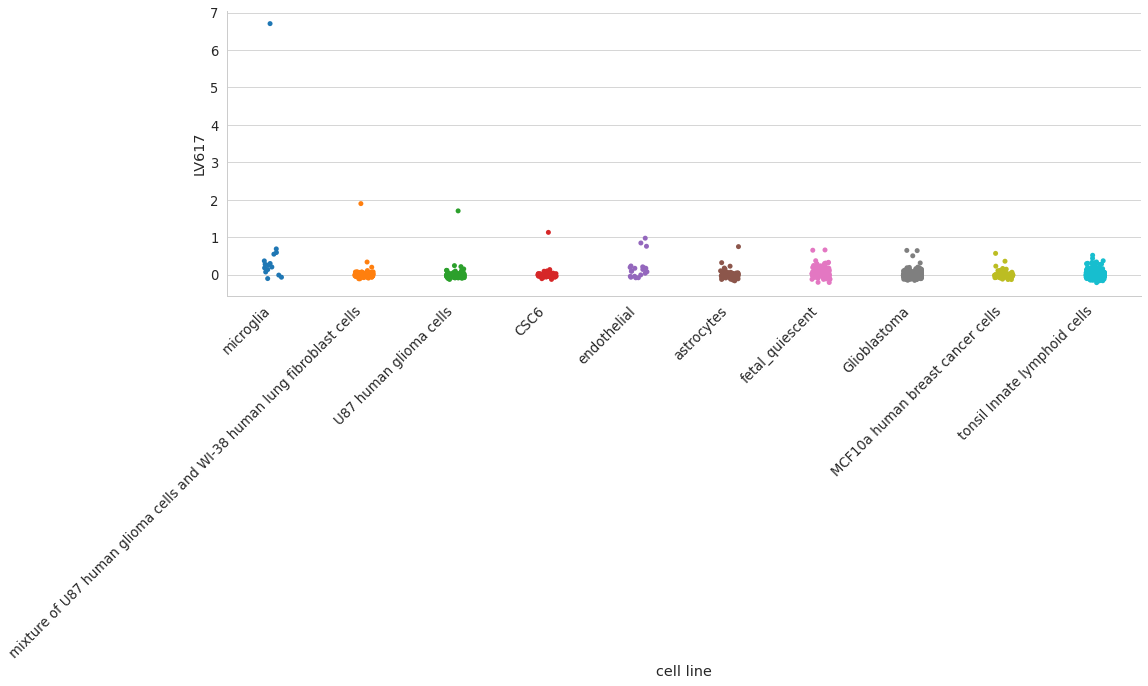

In [38]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

#     plt.savefig(
#         OUTPUT_CELL_TYPE_FILEPATH,
#         bbox_inches="tight",
#         facecolor="white",
#     )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [39]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("microglia")
    ]
    display(_tmp.head(20))

cell line     LV617
project   run                            
SRP057196 SRR1974599  microglia  6.703741
          SRR1974598  microglia  0.691102
          SRR1974591  microglia  0.594786
          SRR1974669  microglia  0.550782
          SRR1974671  microglia  0.370884
          SRR1974666  microglia  0.301597
          SRR1974860  microglia  0.281437
          SRR1974606  microglia  0.256929
          SRR1974582  microglia  0.207355
          SRR1974595  microglia  0.183879
          SRR1974861  microglia  0.139543
          SRR1974788  microglia  0.074771
          SRR1974668  microglia -0.007993
          SRR1974590  microglia -0.064561
          SRR1974868  microglia -0.100724

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [40]:
# what is there in these projects?
lv_data.loc[["SRP057196"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

tissue          cell type                 age  \
project   run                                                              
SRP057196 SRR1974599  hippocampus          microglia  postnatal 54 years   
          SRR1974794  hippocampus        endothelial  postnatal 63 years   
          SRR1974774       cortex        endothelial  postnatal 63 years   
          SRR1974758       cortex        endothelial  postnatal 63 years   
          SRR1974865       cortex         astrocytes  postnatal 47 years   
          SRR1974598  hippocampus          microglia  postnatal 54 years   
          SRR1974969       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974962       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974591  hippocampus          microglia  postnatal 54 years   
          SRR1974669       cortex          microglia  postnatal 63 years   
          SRR1974585  hippocampus                OPC  postnatal 54 years   
          SRR1974876       cortex  fetal_replicating    prenatal 16-18 W   
          SRR1974560       cortex             hybrid  postnatal 54 years   
          SRR1974963       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974671       cortex          microglia  postnatal 63 years   
          SRR1974569       cortex             hybrid  postnatal 54 years   
          SRR1974992       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974871       cortex         astrocytes  postnatal 47 years   
          SRR1975002       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974968       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974690       cortex   oligodendrocytes  postnatal 50 years   
          SRR1974666       cortex          microglia  postnatal 47 years   
          SRR1974901       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974982       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974860       cortex          microglia  postnatal 47 years   
          SRR1974966       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974606       cortex          microglia  postnatal 37 years   
          SRR1974974       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974850       cortex             hybrid  postnatal 21 years   
          SRR1974933       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974932       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974667       cortex        endothelial  postnatal 47 years   
          SRR1974886       cortex  fetal_replicating    prenatal 16-18 W   
          SRR1974733       cortex         astrocytes  postnatal 50 years   
          SRR1974765       cortex   oligodendrocytes  postnatal 63 years   
          SRR1974594  hippocampus                OPC  postnatal 54 years   
          SRR1974760       cortex   oligodendrocytes  postnatal 63 years   
          SRR1974588  hippocampus                OPC  postnatal 54 years   
          SRR1974781       cortex        endothelial  postnatal 63 years   
          SRR1974782       cortex            neurons  postnatal 63 years   
          SRR1974582  hippocampus          microglia  postnatal 54 years   
          SRR1974919       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974768       cortex        endothelial  postnatal 63 years   
          SRR1974561       cortex   oligodendrocytes  postnatal 54 years   
          SRR1974943       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974563       cortex   oligodendrocytes  postnatal 54 years   
          SRR1974804       cortex             hybrid  postnatal 21 years   
          SRR1974595  hippocampus          microglia  postnatal 54 years   
          SRR1974771       cortex        endothelial  postnatal 63 years   
          SRR1974998       cortex    fetal_quiescent    prenatal 16-18 W   
          SRR1974689       cortex         astrocytes  postnatal 50 years   

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.